<a href="https://colab.research.google.com/github/Group11members/CREDIT-CARD-FRAUD-DETECTION-/blob/main/notebooks/Creditcardfrauddetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
## 1. Loading the Dataset
#In this section, we download the credit card fraud dataset from Kaggle and load the CSV file into a Pandas DataFrame.

import pandas as pd
import numpy as np
import os
from os import path
import kagglehub

path= kagglehub.dataset_download("nelgiriyewithana/credit-card-fraud-detection-dataset-2023")
print(path)

Using Colab cache for faster access to the 'credit-card-fraud-detection-dataset-2023' dataset.
/kaggle/input/credit-card-fraud-detection-dataset-2023


In [ ]:
print("This is the content of the path leading to the dataset:")
print(os.listdir(path))

This is the content of the path leading to the dataset:
['creditcard_2023.csv']


In [ ]:
data= pd.read_csv(os.path.join(path, "creditcard_2023.csv"))

In [ ]:
df=pd.DataFrame(data)
print(df)

            id        V1        V2        V3        V4        V5        V6  \
0            0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898   
1            1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605   
2            2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481   
3            3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312   
4            4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549   
...        ...       ...       ...       ...       ...       ...       ...   
568625  568625 -0.833437  0.061886 -0.899794  0.904227 -1.002401  0.481454   
568626  568626 -0.670459 -0.202896 -0.068129 -0.267328 -0.133660  0.237148   
568627  568627 -0.311997 -0.004095  0.137526 -0.035893 -0.042291  0.121098   
568628  568628  0.636871 -0.516970 -0.300889 -0.144480  0.131042 -0.294148   
568629  568629 -0.795144  0.433236 -0.649140  0.374732 -0.244976 -0.603493   

              V7        V8        V9  ...       V21       V22  

In [ ]:
# Inital inspection
# Check the size, columns, data types and general structure of the dataset.

df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [ ]:
df.shape

(568630, 31)

In [ ]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [ ]:
#Checking for missing values
# Check if any column contains empty/missing values.
df.isnull().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:

#Checking for duplicates
# Check if any transaction appears more than once.
df.duplicated().sum()

np.int64(0)

In [ ]:

df.columns

Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.dtypes

,0
id,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
# Checking the target column
# Class is what we want the model to predict: legitimate or fraudulent.

df['Class'].value_counts()

,count
Class,
0,284315
1,284315


In [ ]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.5
1,0.5


In [ ]:

# Checking transaction amounts
# Check the basic range of transaction amounts for any obvious issues.
df['Amount'].describe()

,Amount
count,568630.000000
mean,12041.957635
std,6919.644449
min,50.010000
25%,6054.892500
50%,12030.150000
75%,18036.330000
max,24039.930000


In [ ]:
df['Amount'].min()

50.01

In [ ]:
df['Amount'].max()

24039.93

In [ ]:
np.isinf(df.select_dtypes(include='number')).sum().sum()

np.int64(0)

In [ ]:
(df['Amount'] < 0).sum()

np.int64(0)

In [ ]:
#Checking the ID column
# Check if each transaction has a unique ID before deciding whether to drop it.

df['id'].head()

,id
0,0
1,1
2,2
3,3
4,4


In [ ]:
print("Number of rows:", len(df))
print("Number of unique IDs:", df['id'].nunique())
print("Are all IDs unique?", df['id'].is_unique)

Number of rows: 568630
Number of unique IDs: 568630
Are all IDs unique? True


In [ ]:
# Each transaction has a unique ID, so it is only an identifier and not a useful feature for prediction.
# We will remove it from the data used for modelling.
clean_df = df.drop(columns=['id'])
print(clean_df)

              V1        V2        V3        V4        V5        V6        V7  \
0      -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1       0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2      -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3      -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4      -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   
...          ...       ...       ...       ...       ...       ...       ...   
568625 -0.833437  0.061886 -0.899794  0.904227 -1.002401  0.481454 -0.370393   
568626 -0.670459 -0.202896 -0.068129 -0.267328 -0.133660  0.237148 -0.016935   
568627 -0.311997 -0.004095  0.137526 -0.035893 -0.042291  0.121098 -0.070958   
568628  0.636871 -0.516970 -0.300889 -0.144480  0.131042 -0.294148  0.580568   
568629 -0.795144  0.433236 -0.649140  0.374732 -0.244976 -0.603493 -0.347613   

              V8        V9       V10  .

In [ ]:
!git clone https://github.com/Group11members/CREDIT-CARD-FRAUD-DETECTION-.git

Cloning into 'CREDIT-CARD-FRAUD-DETECTION-'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 16.14 KiB | 295.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
%cd /content/CREDIT-CARD-FRAUD-DETECTION-

/content/CREDIT-CARD-FRAUD-DETECTION-


In [ ]:
!mkdir notebooks

mkdir: cannot create directory ‘notebooks’: File exists


In [ ]:
!ls

notebooks  README.md


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
## Instructions for the Next Team Member

# I have completed Part 1: Data Loading, Inspection and Initial Cleaning.

# The cleaned dataset is stored in the DataFrame called `clean_df`.

#

# To continue with Part 2, open the latest version of this notebook

# from our GitHub repository:

# Group11members/CREDIT-CARD-FRAUD-DETECTION-

#

# The notebook is inside the `notebooks` folder.

#

# Before editing, make sure you have the latest version from GitHub.

# Continue from this point in the same notebook — do not create a new notebook.

#

# Your section is Part 2: Exploratory Data Analysis (EDA).

# You can use `clean_df` directly because the earlier cells have already

# created it.

#

# When you finish your section, save the notebook and push the updated

# version to GitHub so the next team member can continue from your work.

#

# Important: Only one person should edit and push this notebook at a time.

# Make sure you are working with the latest version before starting.


In [ ]:
# Analyzing the class distribution

df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.5
1,0.5


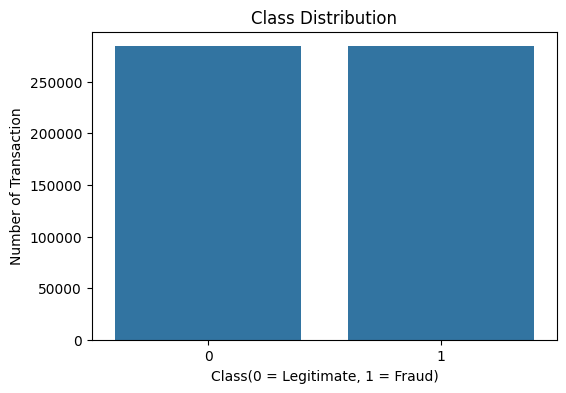

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class')

plt.title('Class Distribution')
plt.xlabel('Class(0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transaction')

plt.show()

The dataset contain an equal proportion of class 0 ans class 1 transactions, therefore the dataset used for this analysis is balanced with respect to the target variable

In [ ]:
# Analyze transaction amount
df['Amount'].describe()

,Amount
count,568630.000000
mean,12041.957635
std,6919.644449
min,50.010000
25%,6054.892500
50%,12030.150000
75%,18036.330000
max,24039.930000


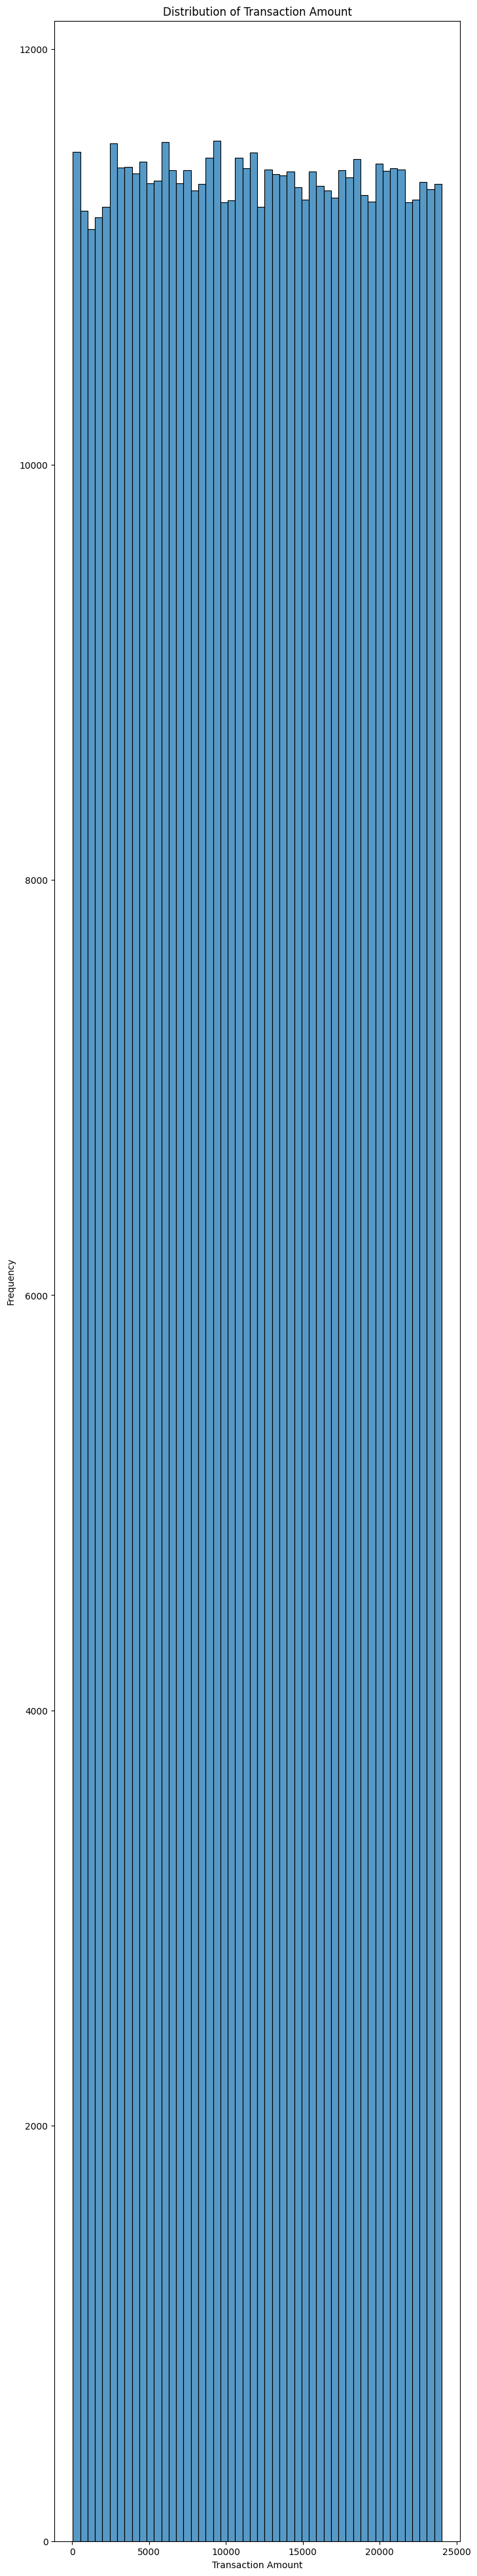

In [ ]:
# Visualize the amount distribution

plt.figure(figsize=(8, 50))
sns.histplot(data=df, x='Amount', bins=50)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

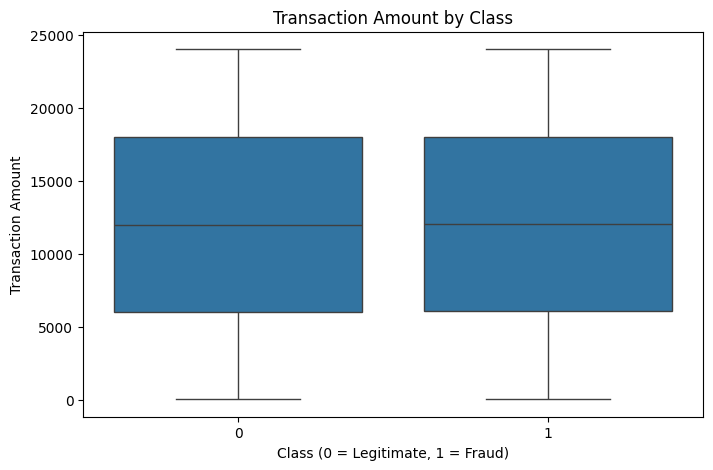

In [ ]:
# Compare Amount between Legitimate and Fraudlent transactions

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Amount')

plt.show()

In [ ]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,12026.313506,6929.500715,50.12,6034.54,11996.90,18040.265,24039.93
1,284315.0,12057.601763,6909.750891,50.01,6074.64,12062.45,18033.780,24039.93


In [ ]:
v_features = [f'V{i}' for i in range(1, 29)]
print(v_features)

df[v_features].describe().T

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


,count,mean,std,min,25%,50%,75%,max
V1,568630.0,-5.638058e-17,1.000001,-3.495584,-0.565286,-0.093638,0.832658,2.229046
V2,568630.0,-1.319545e-16,1.000001,-49.966572,-0.486678,-0.135894,0.343555,4.361865
V3,568630.0,-3.518788e-17,1.000001,-3.183760,-0.649299,0.000353,0.628538,14.125834
V4,568630.0,-2.879008e-17,1.000001,-4.951222,-0.656020,-0.073762,0.707005,3.201536
V5,568630.0,7.997245e-18,1.000001,-9.952786,-0.293496,0.081088,0.439737,42.716891
V6,568630.0,-3.958636e-17,1.000001,-21.111108,-0.445871,0.078718,0.497788,26.168402
V7,568630.0,-3.198898e-17,1.000001,-4.351839,-0.283533,0.233366,0.525955,217.873038
V8,568630.0,2.109273e-17,1.000001,-10.756342,-0.192257,-0.114524,0.047299,5.958040
V9,568630.0,3.998623e-17,1.000001,-3.751919,-0.568745,0.092526,0.559262,20.270062
V10,568630.0,1.991314e-16,1.000001,-3.163276,-0.590101,0.262614,0.592460,31.722709


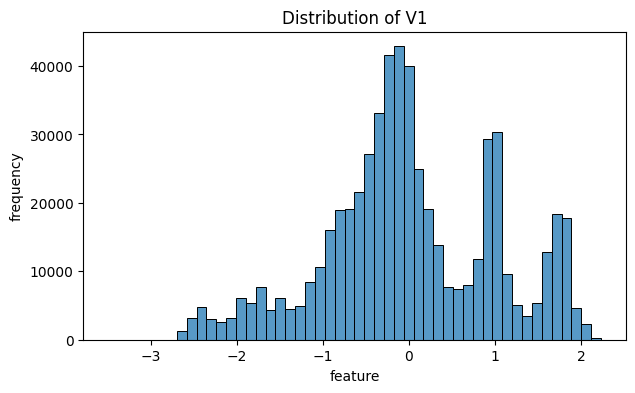

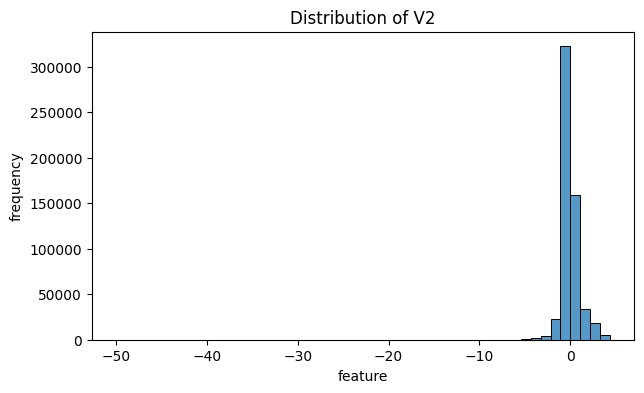

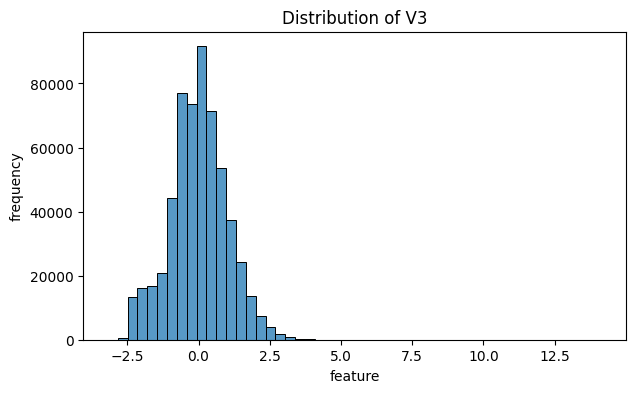

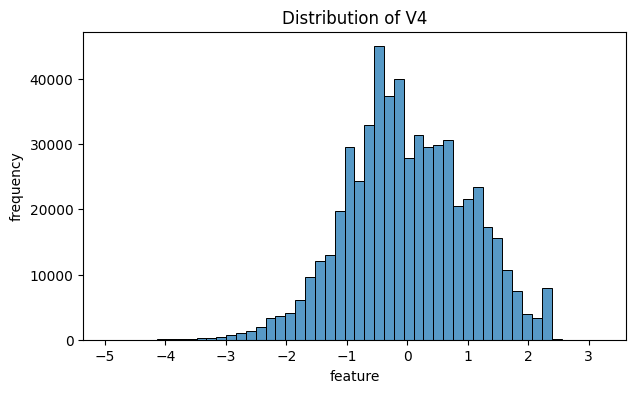

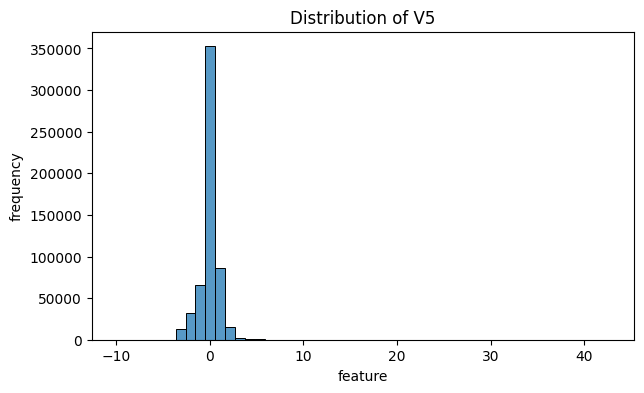

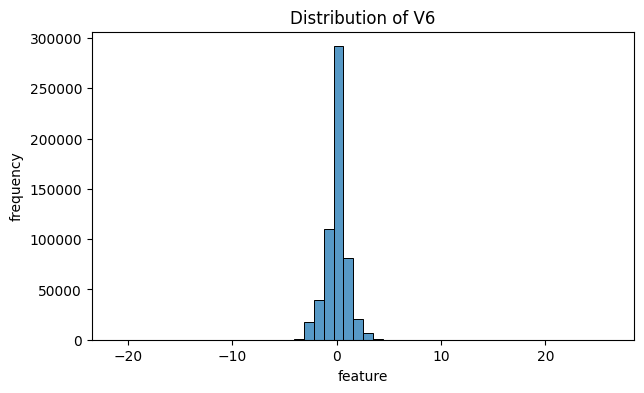

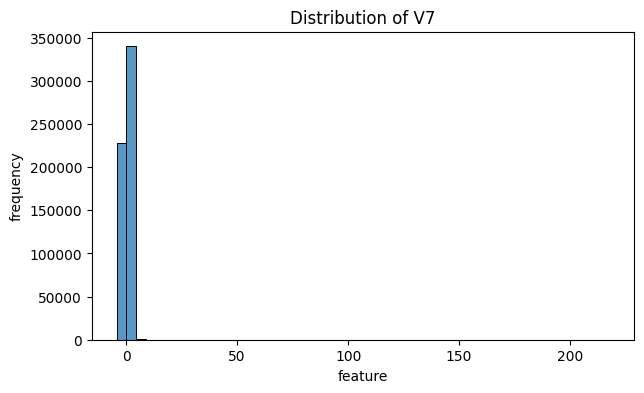

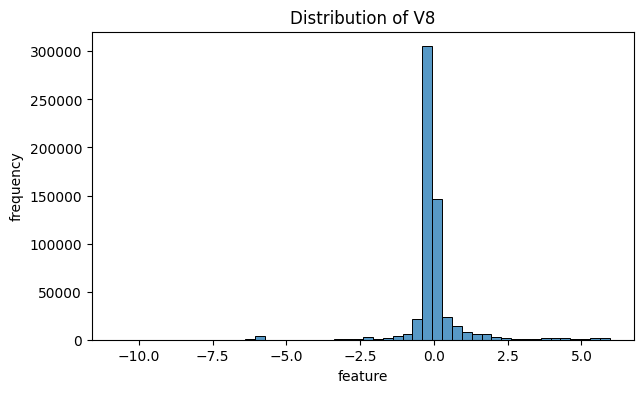

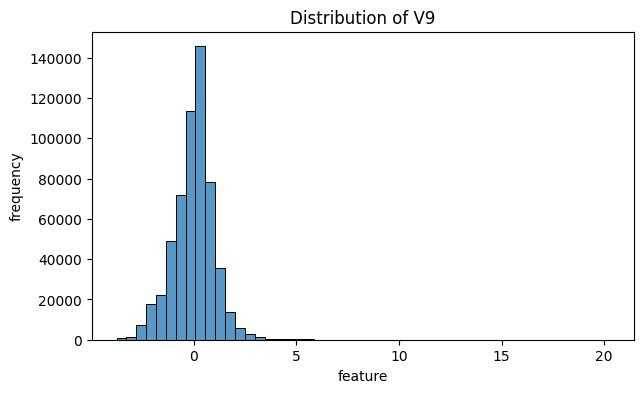

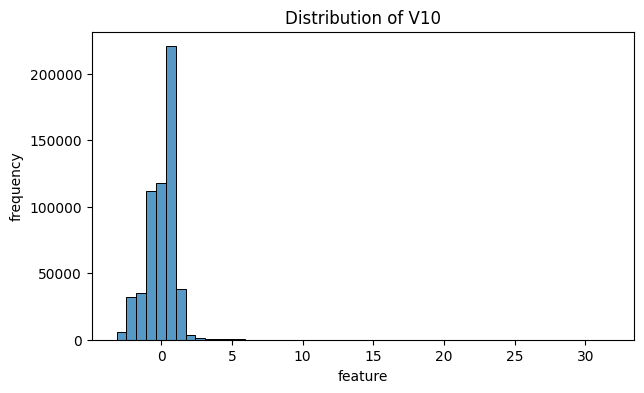

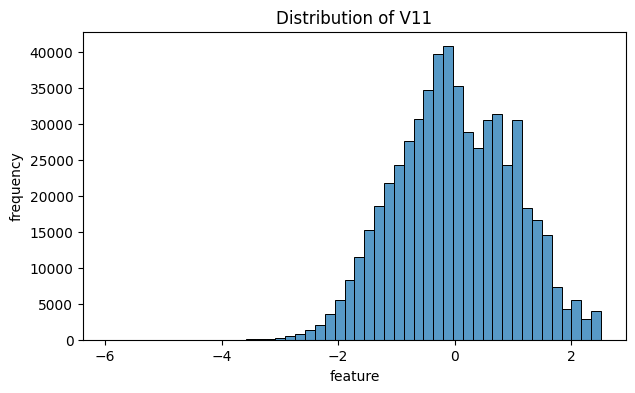

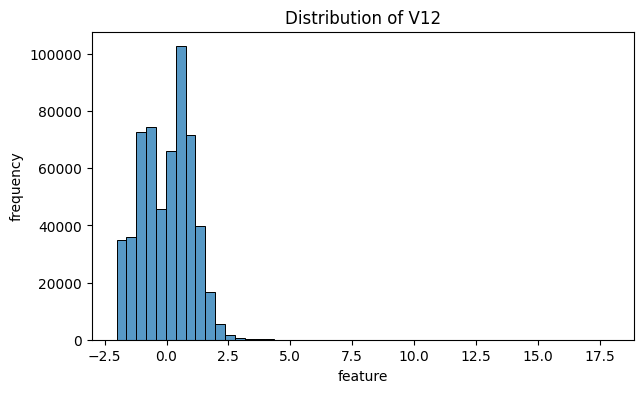

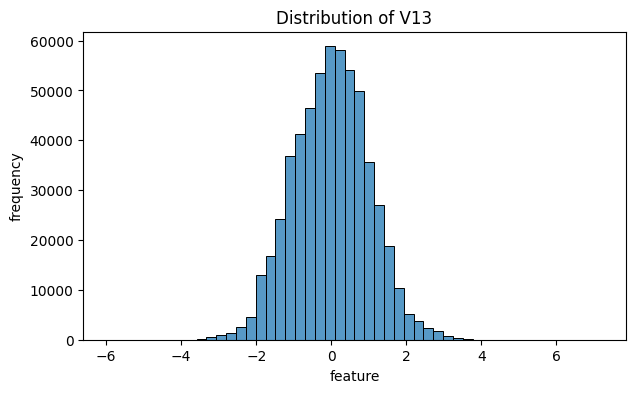

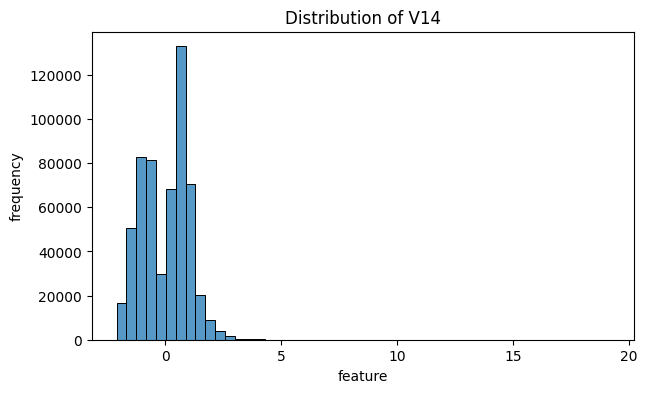

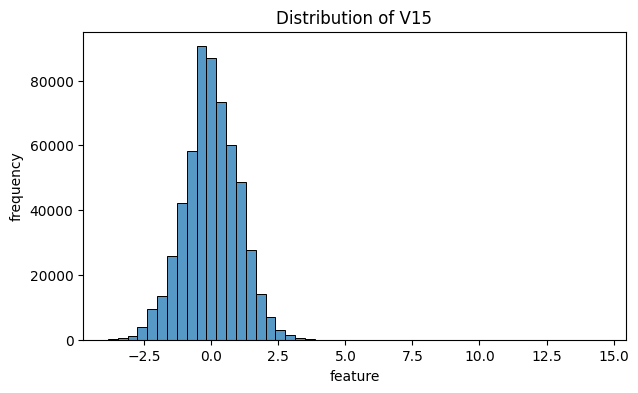

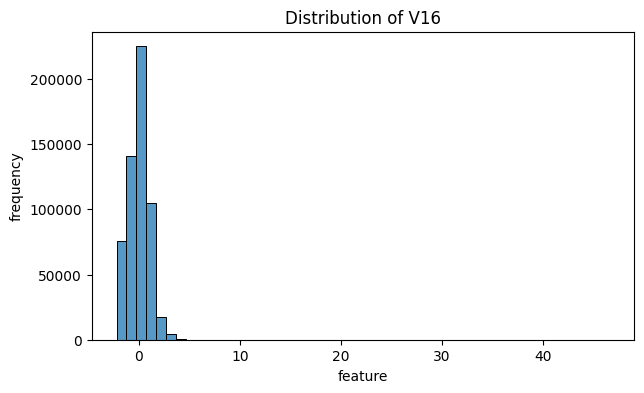

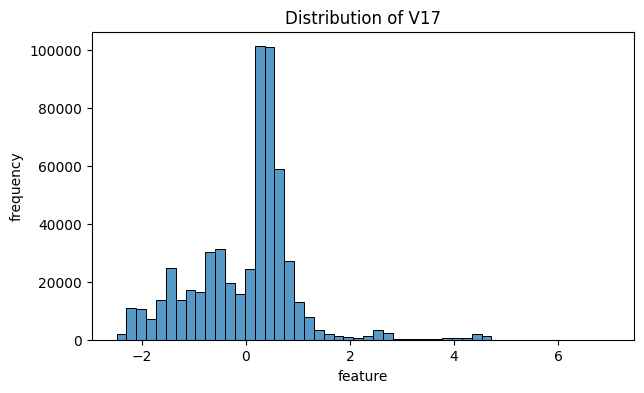

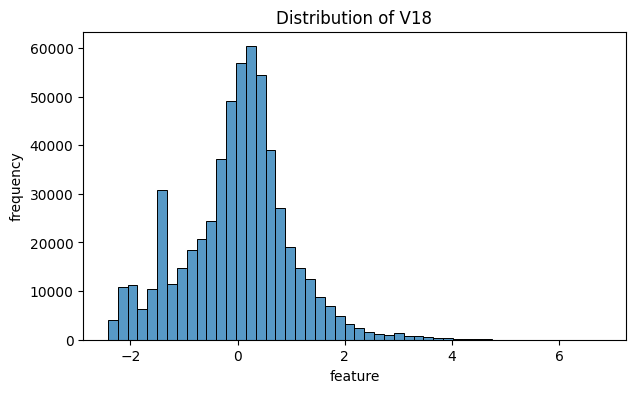

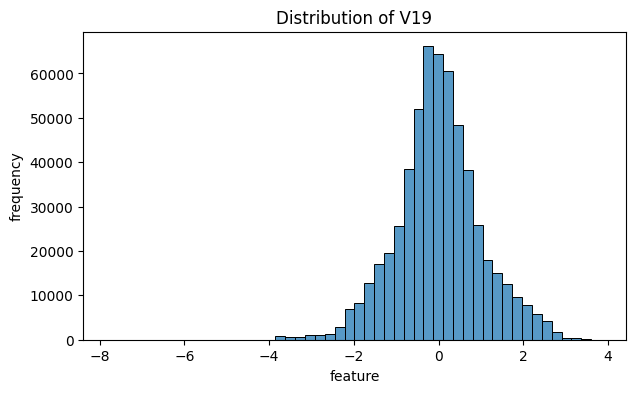

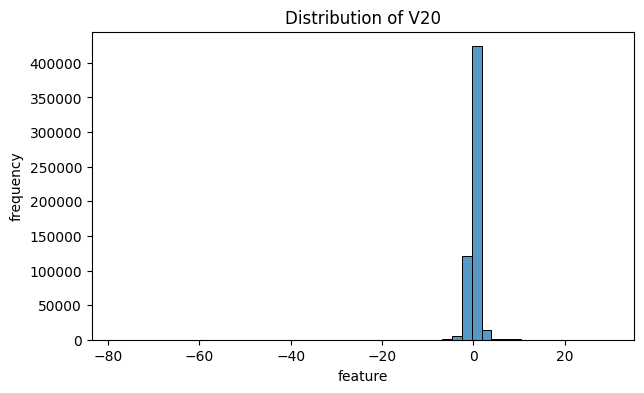

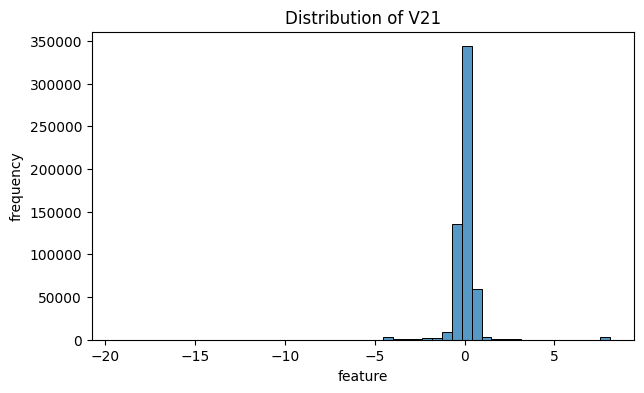

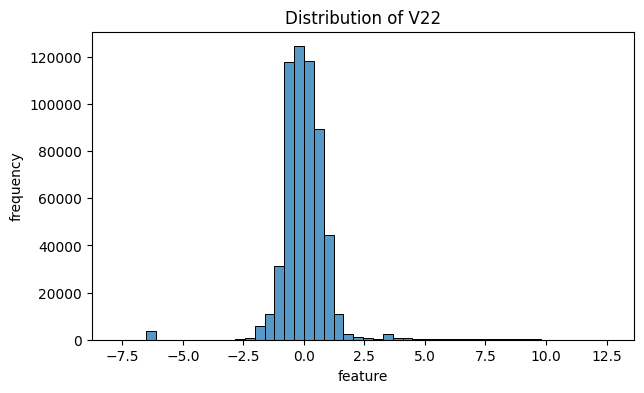

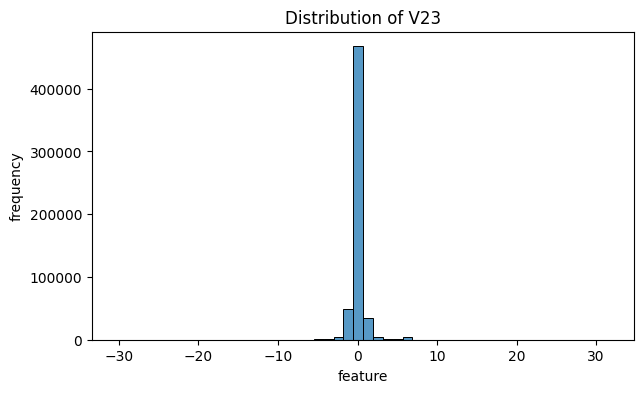

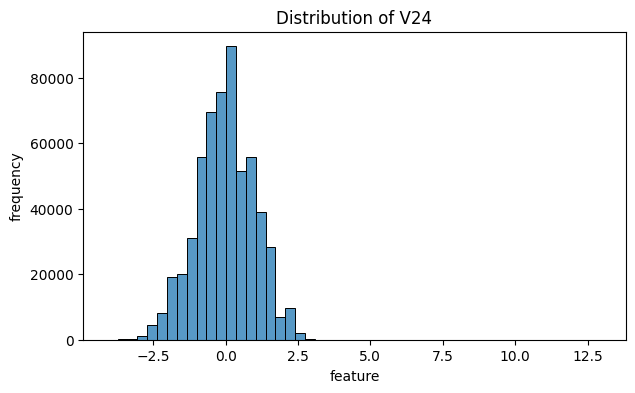

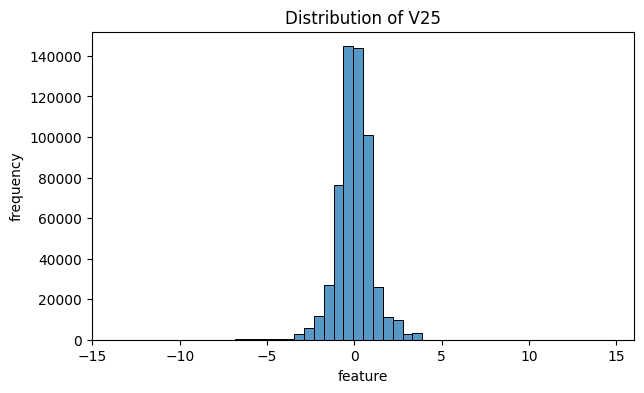

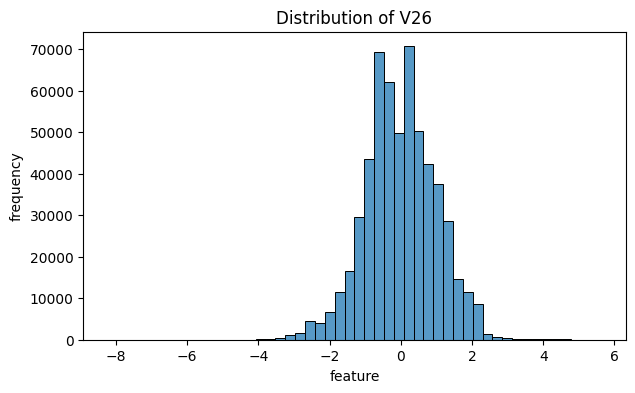

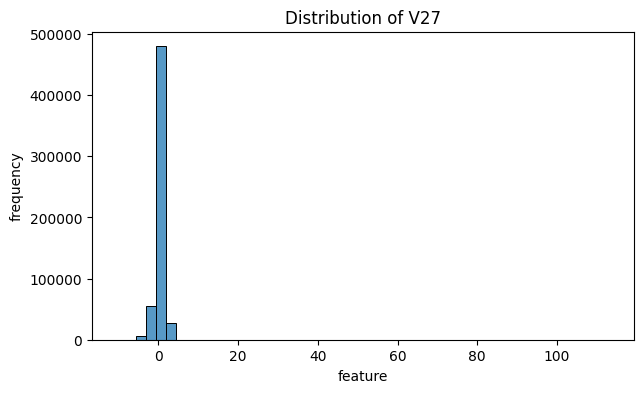

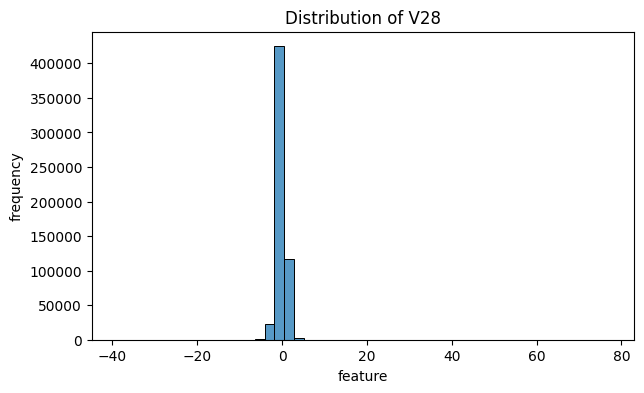

In [ ]:
for feature in v_features:
  plt.figure(figsize=(7, 4))
  sns.histplot(data=df, x=feature, bins=50)

  plt.title(f'Distribution of {feature}')
  plt.xlabel('feature')
  plt.ylabel('frequency')

  plt.show()

In [ ]:
# finding outliers

q1 = df['Amount'].quantile(0.25)
q3 = df['Amount'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -11917.263750000004
Upper Bound: 36008.48625


In [ ]:
outliers = df[
(df['Amount'] < lower_bound) |
(df['Amount'] > upper_bound)
 ]
print("Number of potential outliers:", len(outliers))

Number of potential outliers: 0


In [ ]:
# Identify pattern that may hel fraud detection

In [ ]:
print(df.shape)

(568630, 30)


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (568630, 29)
y shape: (568630,)


In [ ]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Target:
Class


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (454904, 29)
X_test shape: (113726, 29)
y_train shape: (454904,)
y_test shape: (113726,)


In [ ]:
print(X_train.describe().T[['min', 'max', 'mean', 'std']])

              min           max          mean          std
V1      -3.495584      2.225587      0.000346     0.999992
V2     -49.966572      4.361865     -0.000078     1.000224
V3      -3.183760     14.125834      0.000070     0.999781
V4      -4.951222      3.201536      0.000014     0.999915
V5      -9.952786     42.716891     -0.000102     1.000336
V6     -21.111108     26.168402     -0.000177     0.999685
V7      -4.351839    217.873038      0.000715     1.008386
V8     -10.756342      5.958040     -0.000048     0.999616
V9      -3.751919     20.270062      0.000017     0.999583
V10     -3.163276     31.722709     -0.000028     0.998773
V11     -5.954723      2.513485     -0.000273     1.000124
V12     -2.020399     17.913556      0.000631     1.000348
V13     -5.955227      7.187486      0.000099     0.999600
V14     -2.107337     19.169544      0.000157     0.999818
V15     -3.861813     14.532202      0.000509     0.999949
V16     -2.214513     46.652906     -0.000100     1.0003

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
    ('scaler', StandardScaler())
])

In [ ]:

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (454904, 29)
X_test_scaled shape: (113726, 29)


In [ ]:
print(X_train_scaled.mean(axis=0)[:5])
print(X_train_scaled.std(axis=0)[:5])

[-1.96494812e-17 -1.68691890e-17 -1.07306785e-17 -1.06525805e-17
  1.65567966e-17]
[1. 1. 1. 1. 1.]


In [ ]:
print(X_test_scaled.mean(axis=0)[:5])
print(X_test_scaled.std(axis=0)[:5])

[-1.73136051e-03  3.88425405e-04 -3.48477566e-04 -6.79147125e-05
  5.10968678e-04]
[1.00004253 0.99888745 1.00109889 1.00043113 0.99832245]


In [ ]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227452
1    227452
Name: count, dtype: int64

Testing class distribution:
Class
1    56863
0    56863
Name: count, dtype: int64


In [ ]:
X_train_scaled
y_train
X_test_scaled
y_test

,Class
510747,1
390373,1
81077,0
236854,0
407198,1
...,...
260738,0
326576,1
498586,1
443122,1


1.When I started my preprocessing section, I checked the dataset structure and found that the ID column had already been removed earlier in the notebook. The remaining 29 columns consisted of V1 to V28 and Amount, which I used as the predictive features, while Class was the target.

2.I separated the predictive features from the target variable. Class was used as the target, while V1 to V28 and Amount were used as the input features. I printed feature and target to be sure that Id has been removed

3. Since they've checked for missing values and there is none and also value.count has checked for balance and it is.

4. I did training and testing and startification to ensure the distribution remains consistent between testing and training sets.
5. For the feature scaling, I inspected the feature distributions before applying preprocessing. V1 to V28 were already approximately standardized, but Amount was on a considerably larger scale.

6. Because Logistic Regression is sensitive to feature scale, I used StandardScaler to put the features on a comparable scale.( Since logistic regression is the best model for this problem we are solving it helps to classify the spam)

7. To prevent data leakage, I fitted the scaler only on the training data. I then used the same fitted scaler to transform the test data. This ensured that information from the test set did not influence the preprocessing.

8. I checked and noticed the train data had meann of 0  and std of 1 and   test data has mean very close to 0 and standard deviations very close to 1, but not exactly and that's still okay because scaler was fitted on training set I  and checked ifstratifying really worked after training and it did worked and kept test and train balanced.


 My defense focus;

I first inspected the dataset structure and found that the ID column had already been removed before my preprocessing section. I separated the remaining variables into 29 predictive features;V1 to V28 and Amount and the Class; target.
I checked for missing values and found none. I also checked the class distribution and found that the two classes were equally represented.
I then split the data into 80% training and 20% testing using stratification, which preserved the class distribution.
Since the selected algorithm should be  Logistic Regression, I examined the feature scales and applied StandardScaler. I fitted the scaler only on the training data and then used it to transform the test data, which prevented data leakage.
The resulting scaled training and testing features, together with their corresponding targets, were then ready to be passed to the Logistic Regression model